In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
import random
import math
from ipywidgets import IntProgress
from IPython.display import display
from numba import njit
import gc

In [1]:
# =============================================================================
# 1. GÉNÉRATION D'INSTANCE GARANTIE FAISABLE (TSPTW-PC)
# =============================================================================

def genere_instance_complexe(n, precedence_prob=0.1):
    # Des distances plus courtes pour tenir en une journée (5h à 22h)
    mat_temps = np.random.randint(10, 45, size=(n+1, n+1))
    np.fill_diagonal(mat_temps, 0)
    
    # Création d'un chemin "secret" parfait pour garantir qu'une solution existe
    chemin_secret = list(range(1, n+1))
    random.shuffle(chemin_secret)
    
    e = np.zeros(n+1)
    l = np.full(n+1, 1320.0) # 1320 = 22h00
    s = np.random.randint(5, 15, size=n+1) # Temps de service courts
    s[0] = 0
    
    t_actuel = 300.0 # Départ à 5h00
    noeud_prec = 0
    
    # On assigne les fenêtres de temps en simulant le trajet parfait
    for noeud in chemin_secret:
        t_actuel += mat_temps[noeud_prec][noeud]
        
        # Fenêtre logique autour de l'heure d'arrivée prévue
        e[noeud] = max(300, t_actuel - random.randint(10, 45))
        l[noeud] = min(1320, t_actuel + random.randint(45, 120))
        
        t_actuel += s[noeud]
        noeud_prec = noeud
        
    # Précédences basées uniquement sur l'ordre du chemin secret
    P = []
    for idx, i in enumerate(chemin_secret):
        for j in chemin_secret[idx+1:]:
            if random.random() < precedence_prob:
                P.append((i, j))
                
    return mat_temps, e, l, s, P

def formater_temps(total_mins):
    """Affiche un format Heure propre, ou signale une tournée invalide"""
    if np.isnan(total_mins):
        return "[Non trouvé / Invalide]"
    if total_mins > 2000: # Si la pénalité a explosé le compteur
        return f"🚨 [INVALIDE - Score pénalité : {int(total_mins)}]"
        
    heures = int(total_mins // 60)
    mins = int(total_mins % 60)
    return f"{heures}h{mins:02d}"

In [23]:
# =============================================================================
# 2. LOGIQUE TEMPORELLE (5h-22h)
# =============================================================================

@njit
def calcul_temps_trajet_reel(temps_actuel, trajet_min):
    """
    Gère la contrainte 22h-5h. Si on dépasse 22h (1320), 
    on attend jusqu'à 5h (300) le lendemain.
    """
    arrivee = temps_actuel + trajet_min
    
    # Heure dans la journée actuelle
    heure_dans_jour = arrivee % 1440
    
    if heure_dans_jour > 1320: # Il est plus de 22h
        # On passe au lendemain 5h du matin
        nb_jours = arrivee // 1440
        arrivee = (nb_jours + 1) * 1440 + 300
        
    return arrivee

def formater_temps(total_mins):
    """Convertit les minutes en Jours, Heures, Minutes"""
    jours = int(total_mins // 1440)
    reste = total_mins % 1440
    heures = int(reste // 60)
    mins = int(reste % 60)
    return f"{jours}j {heures}h {mins}min"

In [24]:
# =============================================================================
# 3. FONCTION DE COÛT (ÉVALUATION AVEC PÉNALITÉS STRICTES)
# =============================================================================

@njit
def evalue_tournee_complexe(path, mat, e, l, s, P_array):
    temps_cumule = 300.0 # 5h du matin
    penalite = 0.0
    M = 1000.0 # La pénalité n'a plus besoin d'être extrême
    
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        temps_cumule += mat[u, v]
        
        if temps_cumule < e[v]:
            temps_cumule = e[v] # On attend l'ouverture
        elif temps_cumule > l[v]:
            penalite += (temps_cumule - l[v]) * M # En retard !
            
        temps_cumule += s[v]
        
    temps_cumule += mat[path[-1], path[0]]
    
    # Dépassement 22h00
    if temps_cumule > 1320:
        penalite += (temps_cumule - 1320) * M
        
    for k in range(len(P_array)):
        avant, apres = P_array[k]
        idx_avant = -1
        idx_apres = -1
        for idx in range(len(path)):
            if path[idx] == avant: idx_avant = idx
            if path[idx] == apres: idx_apres = idx
        
        if idx_avant > idx_apres:
            penalite += M * 50
            
    return temps_cumule + penalite

In [25]:
# =============================================================================
# 4. MÉTHODES DE RÉSOLUTION
# =============================================================================

def resolution_PuLP_Exact(mat, e, l, s, P, timeout=60):
    n = len(mat) - 1
    prob = LpProblem("TSPTW_PC", LpMinimize)
    
    x = LpVariable.dicts("x", (range(n+1), range(n+1)), cat=LpBinary)
    T = LpVariable.dicts("T", range(n+1), lowBound=0, cat=LpContinuous)
    
    prob += lpSum(mat[i][j] * x[i][j] for i in range(n+1) for j in range(n+1) if i != j)
    
    for i in range(n+1):
        prob += lpSum(x[i][j] for j in range(n+1) if i != j) == 1
        prob += lpSum(x[j][i] for j in range(n+1) if i != j) == 1

    M = 10000
    for i in range(n+1):
        prob += T[i] >= e[i]
        prob += T[i] <= l[i]
        for j in range(1, n+1):
            if i != j:
                prob += T[i] + s[i] + mat[i][j] - M*(1 - x[i][j]) <= T[j]

    for (i, j) in P:
        prob += T[i] + s[i] + mat[i][j] <= T[j]

    # Contrainte globale 22h max
    for i in range(n+1):
        prob += T[i] <= 1320

    prob.solve(PULP_CBC_CMD(msg=0, timeLimit=timeout))
    
    if prob.status == 1: # Solution Optimale trouvée
        return value(prob.objective)
    else: # Infeasible ou Timeout
        return np.nan

def borne_inferieure_TSP(mat):
    n = len(mat) - 1
    prob = LpProblem("Borne_Inf", LpMinimize)
    x = LpVariable.dicts("x", (range(n+1), range(n+1)), lowBound=0, upBound=1, cat=LpContinuous)
    prob += lpSum(mat[i][j] * x[i][j] for i in range(n+1) for j in range(n+1) if i != j)
    for i in range(n+1):
        prob += lpSum(x[i][j] for j in range(n+1) if i != j) == 1
        prob += lpSum(x[j][i] for j in range(n+1) if i != j) == 1
    prob.solve(PULP_CBC_CMD(msg=0))
    # La borne inferieure ne prend pas en compte le service ni les temps d'attente
    # On y ajoute la base du temps (5h = 300) pour être cohérent avec le graphique
    return value(prob.objective) + 300 

@njit(cache=True)
def recuit_simule_adaptatif_numba(initial_path, mat, e, l, s, P_array, t_init=5000.0, alpha=0.99, iter_plateau=100):
    current_path = initial_path.copy()
    current_cost = evalue_tournee_complexe(current_path, mat, e, l, s, P_array)
    
    best_path = current_path.copy()
    best_cost = current_cost
    
    T = t_init
    
    # La température baisse progressivement jusqu'à 0.1
    while T > 0.1:
        # LE PALIER : On teste plein de voisins à la même température
        for _ in range(iter_plateau):
            idx1 = np.random.randint(1, len(current_path)-1)
            idx2 = np.random.randint(1, len(current_path)-1)
            
            # Si on tire la même ville, on passe
            if idx1 == idx2:
                continue
                
            new_path = current_path.copy()
            new_path[idx1], new_path[idx2] = new_path[idx2], new_path[idx1]
            
            new_cost = evalue_tournee_complexe(new_path, mat, e, l, s, P_array)
            delta = new_cost - current_cost
            
            # Critère d'acceptation
            if delta < 0 or np.random.random() < np.exp(-delta / T):
                current_path = new_path
                current_cost = new_cost
                
                # Sauvegarde du meilleur absolu
                if current_cost < best_cost:
                    best_cost = current_cost
                    best_path = current_path.copy()
        
        # On ne baisse la température qu'à la fin du palier
        T *= alpha
            
    return best_cost

IntProgress(value=0, description='Calculs:', layout=Layout(width='100%'), max=6)


--- Test avec 5 sommets ---
Borne Inférieure (Idéal)   : 0j 6h 42min
Optimum Mathématique (PuLP): 0j 7h 46min
Recuit Adaptatif (Numba)   : 0j 8h 15min | Écart : +6.22% | (T=2500.0, a=0.980, plat=500)

--- Test avec 10 sommets ---
Borne Inférieure (Idéal)   : 0j 7h 28min
Optimum Mathématique (PuLP): 0j 10h 33min
Recuit Adaptatif (Numba)   : 218j 13h 29min | Écart : +49620.22% | (T=5000.0, a=0.990, plat=1000)

--- Test avec 15 sommets ---
Borne Inférieure (Idéal)   : 0j 8h 20min
Optimum Mathématique (PuLP): 0j 12h 2min
Recuit Adaptatif (Numba)   : 268j 14h 55min | Écart : +53475.48% | (T=7500.0, a=0.993, plat=1500)

--- Test avec 20 sommets ---
Borne Inférieure (Idéal)   : 0j 9h 12min
Optimum Mathématique (PuLP): [Ignoré - Instance trop complexe]
Recuit Adaptatif (Numba)   : 414j 14h 57min | (T=10000.0, a=0.995, plat=2000)

--- Test avec 25 sommets ---
Borne Inférieure (Idéal)   : 0j 10h 9min
Optimum Mathématique (PuLP): [Ignoré - Instance trop complexe]
Recuit Adaptatif (Numba)   : 509

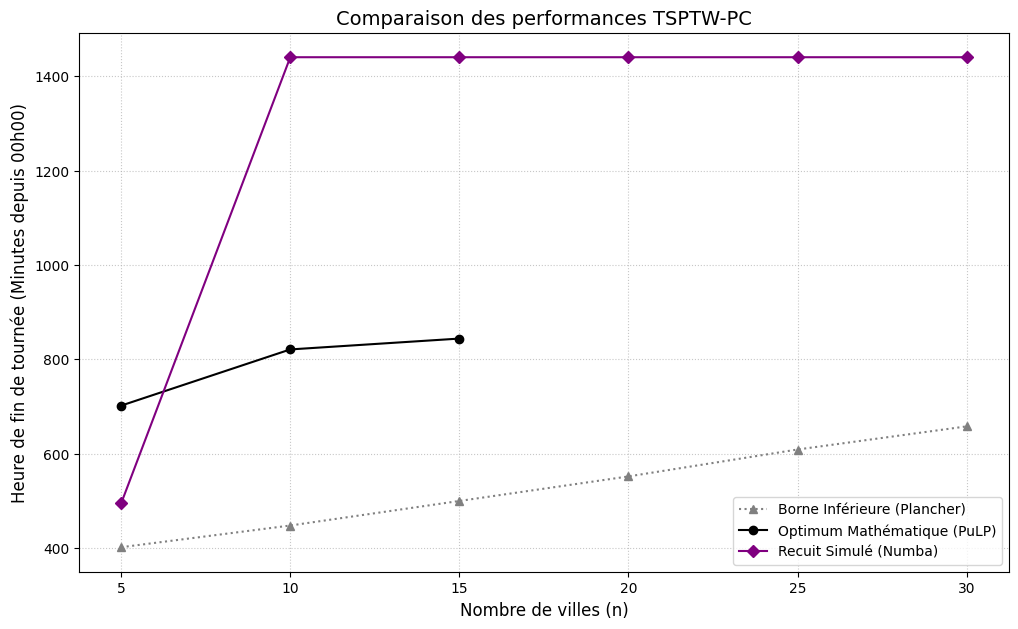

In [26]:
# =============================================================================
# 5. MAIN BENCHMARK
# =============================================================================

def main():
    plt.close('all') 
    gc.collect()
    
    sizes = range(5, 31, 5)
    results = {"Borne": [], "Exact": [], "SA": []}
    
    progress = IntProgress(min=0, max=len(sizes), description='Calculs:', layout={"width" : "100%"})
    display(progress)
    
    for n in sizes:
        print(f"\n" + "="*50)
        print(f"--- Test avec {n} sommets ---")
        print("="*50)
        
        mat, e, l, s, P = genere_instance_complexe(n)
        P_array = np.array(P) if len(P) > 0 else np.empty((0, 2), dtype=np.int64)
        
        # --- Borne Inférieure ---
        res_borne = borne_inferieure_TSP(mat)
        results["Borne"].append(res_borne)
        print(f"Borne Inférieure (Idéal)   : {formater_temps(res_borne)}")
        
        # --- PuLP Exact ---
        if n <= 15: 
            res_exact = resolution_PuLP_Exact(mat, e, l, s, P, timeout=60)
            results["Exact"].append(res_exact)
            if not np.isnan(res_exact):
                # Ajout de 300 pour le temps absolu (Départ à 5h) et des temps de services
                temps_absolu_exact = res_exact + 300 + sum(s)
                print(f"Optimum Mathématique (PuLP): {formater_temps(temps_absolu_exact)}")
            else:
                print(f"Optimum Mathématique (PuLP): [Timeout ou Impossible]")
        else:
            results["Exact"].append(np.nan)
            print(f"Optimum Mathématique (PuLP): [Ignoré - Instance trop complexe]")
            
        # --- Recuit Simulé ---
# ==========================================
        # --- PARAMÈTRES DYNAMIQUES ADAPTATIFS ---
        # ==========================================
        # 1. Température très haute pour accepter les grosses pénalités au début
        dynamic_temp = float(n * 500) 
        
        # 2. Refroidissement lent qui s'adapte à la taille (plus c'est grand, plus c'est proche de 1)
        dynamic_alpha = float(1.0 - (0.1 / n)) 
        
        # 3. La taille du palier : on teste 'n * 100' voisins avant de refroidir
        dynamic_plateau = int(n * 100) 
        
        # --- Recuit Simulé ---
        initial_path = np.arange(n+1)
        res_sa = recuit_simule_adaptatif_numba(initial_path, mat, e, l, s, P_array, 
                                               t_init=dynamic_temp, 
                                               alpha=dynamic_alpha, 
                                               iter_plateau=dynamic_plateau)
        results["SA"].append(res_sa)
        
        # Affichage avec l'écart si PuLP est disponible
        if not np.isnan(results["Exact"][-1]):
            temps_absolu_exact = results["Exact"][-1] + 300 + sum(s)
            ecart = ((res_sa - temps_absolu_exact) / temps_absolu_exact) * 100
            print(f"Recuit Adaptatif (Numba)   : {formater_temps(res_sa)} | Écart : +{ecart:.2f}% | (T={dynamic_temp}, a={dynamic_alpha:.3f}, plat={dynamic_plateau})")
        else:
            print(f"Recuit Adaptatif (Numba)   : {formater_temps(res_sa)} | (T={dynamic_temp}, a={dynamic_alpha:.3f}, plat={dynamic_plateau})")
            
        progress.value += 1
        gc.collect()

    progress.close()

    plt.figure(figsize=(12, 7))
    plt.plot(sizes, results["Borne"], marker='^', linestyle=':', label="Borne Inférieure (Plancher)", color='gray')
    
    # On reconstruit les données PuLP pour le graphique
    pulp_y = [r + 300 + sum(s) if not np.isnan(r) else np.nan for r in results["Exact"]]
    plt.plot(sizes, pulp_y, marker='o', linestyle='-', label="Optimum Mathématique (PuLP)", color='black')
    
    # Pour le graphique SA, on sature la valeur si elle a explosé pour ne pas ruiner l'échelle
    sa_y = [min(r, 1440) if r is not None else np.nan for r in results["SA"]]
    plt.plot(sizes, sa_y, marker='D', linestyle='-', label="Recuit Simulé (Numba)", color='purple')
    
    plt.xlabel("Nombre de villes (n)", fontsize=12)
    plt.ylabel("Heure de fin de tournée (Minutes depuis 00h00)", fontsize=12)
    plt.title("Comparaison des performances TSPTW-PC", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()
    
    gc.collect()

if __name__ == "__main__":
    main()